In [3]:
from models.visionlms.llava.llava import Llava, LlavaKVOpt
from IPython.display import Image
import os
import json
import torch
from utils.gpu import clean_gpu_cache

In [4]:
device_num=5
clean_gpu_cache(device_num=device_num)

device = f'cuda:{device_num}' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
llava = LlavaKVOpt(verbose=True).to(device, dtype=torch.bfloat16)

[GPU 5] allocated: 0.000 GB
[GPU 5] reserved : 0.000 GB
Device: cuda:5


Loading checkpoint shards: 100%|██████████| 3/3 [00:01<00:00,  1.77it/s]
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Patched models.visionlms.llava.modeling_llama_kv_opt
Patched LlamaMLP
Patched LlamaRMSNorm

=== Quick Weight Comparison ===
embed_tokens.weight: ✓ Equal
layers.0.self_attn.q_proj.weight: ✓ Equal
layers.0.self_attn.k_proj.weight: ✓ Equal
layers.0.self_attn.v_proj.weight: ✓ Equal
layers.0.self_attn.o_proj.weight: ✓ Equal
... (showing first 5, all others follow same pattern)

=== Comprehensive Check ===

Total parameters checked: 290
Mismatches: 0
Result: ✓ All weights match!

=== Reference Model Frozen Check ===
All reference params frozen: True
Reference model in eval mode: True


In [5]:
question_rows = []
# Open the file and iterate over each line
with open('/app/datasets/llava-bench/questions.jsonl', 'r', encoding="utf-8") as f:
    for line in f:
        # Parse each line (a JSON string) into a Python dictionary
        try:
            json_object = json.loads(line)
            question_rows.append(json_object)
        except json.JSONDecodeError as e:
                print(f"Error decoding JSON on line: {e}")

gpt_rows = []
# Open the file and iterate over each line
with open('/app/datasets/llava-bench/answers_gpt4.jsonl', 'r', encoding="utf-8") as f:
    for line in f:
        # Parse each line (a JSON string) into a Python dictionary
        try:
            json_object = json.loads(line)
            gpt_rows.append(json_object)
        except json.JSONDecodeError as e:
                print(f"Error decoding JSON on line: {e}")                        

In [6]:
import os

example = 4 # hallucinations: 4, ,43, 52, 45,39,  36(?), 30(?)

image_path = os.path.join('/app/datasets/llava-bench/images', question_rows[example]['image'])
instruction = question_rows[example]['text']
gpt_answer = gpt_rows[example]['text']


insturc = 'What type of fruit is this? , pomegranate or something else?'

inputs = llava.get_inputs_for_forward(
    instruction=insturc,
    image_path=image_path,
    device_num=device_num
)

[GPU 5] allocated: 25.474 GB
[GPU 5] reserved : 25.502 GB
modality_bos_idx: 5 | modality_eos_idx: 580

---------------------
Generation step: 0
Adam step: 0
student forward...
reference forward...
KL: -0.0030 | Relevance: 0.5078 | Overall loss: -0.5117
λ_kl X kl: -0.0021 | λ_relevance X relevance: 0.5078

---------------------
Generation step: 1
Adam step: 0
student forward...
reference forward...
KL: 0.0022 | Relevance: 0.5117 | Overall loss: -0.5117
λ_kl X kl: 0.0016 | λ_relevance X relevance: 0.5117

---------------------
Generation step: 2
Adam step: 0
student forward...
reference forward...
KL: -0.0007 | Relevance: 0.5117 | Overall loss: -0.5117
λ_kl X kl: -0.0005 | λ_relevance X relevance: 0.5117

---------------------
Generation step: 3
Adam step: 0
student forward...
reference forward...
KL: 0.0007 | Relevance: 0.5078 | Overall loss: -0.5078
λ_kl X kl: 0.0005 | λ_relevance X relevance: 0.5078

---------------------
Generation step: 4
Adam step: 0
student forward...
reference fo

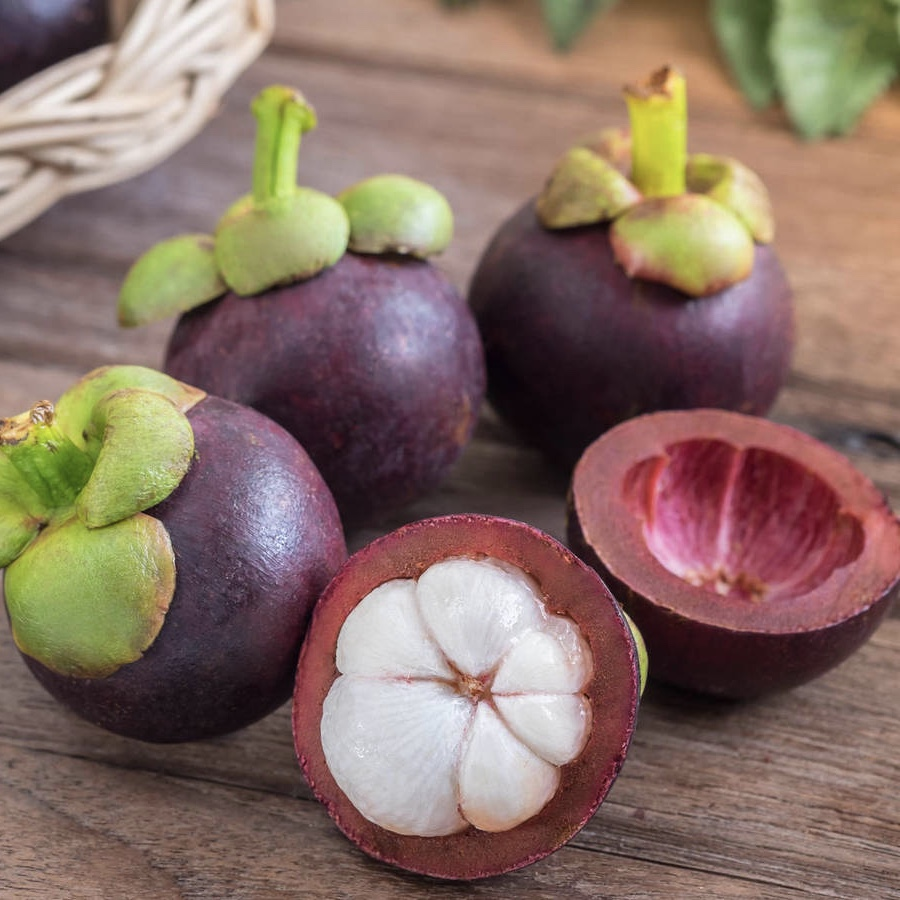

In [8]:
from IPython.display import Image

approach = 'opt'
opt_steps = 1
opt_lr = 1e-2
lambda_kl = 7e-1
lambda_relevance = 1

clean_gpu_cache(device_num=device_num)

llava_answer = llava.generate(
    inputs=inputs,
    approach=approach,
    opt_steps=opt_steps,
    opt_lr=opt_lr,
    lambda_kl=lambda_kl,
    lambda_relevance=lambda_relevance,
    max_new_tokens=170,
    plot=False,
)

print(f'Queestion: {insturc}')
print(f'GPT4 answer: {gpt_answer}')
print(f'Llava answer: {llava_answer}')

Image(filename=image_path, width=400, height=300) 